In this notebook Seamese network model for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torchvision

In [18]:
!pip install timm

In [19]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import timm

In [4]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


In [5]:
drive.mount('/content/drive')


zip_path = '/content/drive/MyDrive/patches_one_line.zip'  # измените путь

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/data')

DATA_ROOT = '/content/data/patches_one_line'
print(f"Authors: {len(os.listdir(DATA_ROOT))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authors: 657


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [6]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 min_height=100, max_height=500, authors_list=None):
        self.transform = transform
        self.size = size
        self.min_height = min_height
        self.max_height = max_height

        self.authors_data = {}

        # Scan folders
        if authors_list is not None:
            folders_to_scan = [f for f in os.listdir(root) if f in authors_list]
        else:
            folders_to_scan = os.listdir(root)

        for folder in folders_to_scan:
            author_path = os.path.join(root, folder)
            if not os.path.isdir(author_path):
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        height = img.size[1]
                    if self.min_height <= height <= self.max_height:
                        valid_images.append(img_path)
                except Exception:
                    continue

            if valid_images:
                self.authors_data[author_path] = valid_images

        # Filter authors with at least 2 images (for positive pairs)
        self.authors_positive = [a for a, imgs in self.authors_data.items() if len(imgs) >= 2]
        self.authors_all = list(self.authors_data.keys())

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Anchor and Positive: same author
        author = random.choice(self.authors_positive)
        images = self.authors_data[author]
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        if len(self.authors_all) < 2:
            # Fallback: use same author but different image
            negative_author = author
            negative_images = [p for p in images if p != anchor_path and p != positive_path]
            if not negative_images:
                negative_images = images
            negative_path = random.choice(negative_images)
        else:
            negative_author = random.choice(self.authors_all)
            while negative_author == author:
                negative_author = random.choice(self.authors_all)
            negative_path = random.choice(self.authors_data[negative_author])

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')


        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

In [7]:
#splitting authors into train and val
import random
all_authors = [f for f in os.listdir(DATA_ROOT)
               if os.path.isdir(os.path.join(DATA_ROOT, f))]
random.shuffle(all_authors)

split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}, Val authors: {len(val_authors)}")

Train authors: 525, Val authors: 132


In [8]:
class ResizeTextPatch:
    """
    Adaptive resize of wide patches.
    Preserve propotions target_h × target_w.
    """
    def __init__(self, target_h=192, target_w=512):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        w, h = img.size  # PIL: width, height

        # Calculating scale
        scale_h = self.target_h / h
        scale_w = self.target_w / w
        scale = min(scale_h, scale_w)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resizing with interpolation
        img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BICUBIC)

        # Creating black square
        new_img = Image.new('L', (self.target_w, self.target_h), 0)

        # Centerring the image
        paste_x = (self.target_w - new_w) // 2
        paste_y = (self.target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img

In [9]:
train_transform = T.Compose([
    T.Resize((224, 224)),  # готовый ресайз
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)  # можно передать без списка
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [ ]:
# train_transform = T.Compose([

#     ResizeTextPatch(target_h=384, target_w=1014),
#     T.RandomRotation(3),
#     T.RandomAffine(
#         degrees=0,
#         translate=(0.02, 0.02),
#         scale=(0.98, 1.02)
#     ),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485], std=[0.229])  # ImageNet stats for 1 channel
# ])

# val_transform = T.Compose([
#     ResizeTextPatch(target_h=384, target_w=1014),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485], std=[0.229])
# ])

In [10]:
train_dataset = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform,
    size=2500,
    min_height=100,
    max_height=500,
    authors_list=train_authors
)

val_dataset = TripletDataset(
    root=DATA_ROOT,
    transform=val_transform,
    size=2000,
    min_height=100,
    max_height=500,
    authors_list=val_authors
)

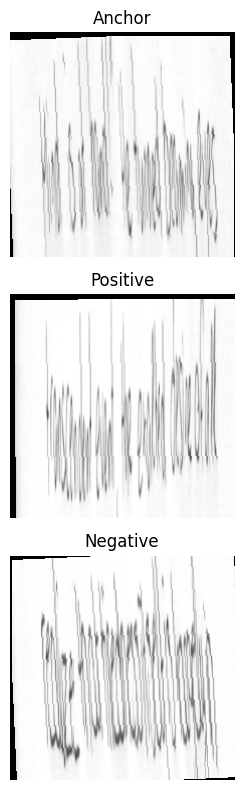

In [11]:
anchor, positive, negative= train_dataset[3]

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.imshow(anchor[0], cmap='gray')
plt.title(f"Anchor")
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(positive[0], cmap='gray')
plt.title("Positive")
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(negative[0], cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one, in moderate except for 2 lasts.For training we use Contrastive loss+BCE

In [14]:
class TripletNetwork(nn.Module):
    def __init__(self, embedding_size=256, model_name='vit_base_patch16_224',
                 pretrained=True, freeze_mode="aggressive"):
        super(TripletNetwork, self).__init__()

        # Load ViT
        self.vit = timm.create_model(model_name, pretrained=pretrained)

        # Adapt first layer for 1 channel
        old_conv = self.vit.patch_embed.proj
        new_conv = nn.Conv2d(1, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding,
                             bias=False)
        with torch.no_grad():
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.vit.patch_embed.proj = new_conv

        # Remove classifier head
        if hasattr(self.vit, 'head'):
            in_features = self.vit.head.in_features
            self.vit.head = nn.Identity()
        else:
            in_features = self.vit.num_features

        # Freeze layers (optional)
        if freeze_mode == "aggressive":
            for param in self.vit.parameters():
                param.requires_grad = False
            # Unfreeze last blocks
            for i, block in enumerate(self.vit.blocks):
                if i >= len(self.vit.blocks) - 2:
                    for param in block.parameters():
                        param.requires_grad = True
            for param in self.vit.norm.parameters():
                param.requires_grad = True
            for param in self.vit.patch_embed.proj.parameters():
                param.requires_grad = True

        # Embedding head (projects features to embedding space)
        self.embedding = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.vit(x)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalize for stable training

    def forward(self, anchor, positive, negative):
        # Все три входа проходят через одну и ту же сеть (shared weights)
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)

        return emb_anchor, emb_positive, emb_negative

In [15]:
class TripletLoss(nn.Module):
    """
    Triplet Loss for metric learning.
    Encourages embeddings of anchor and positive to be closer than anchor and negative.
    """
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        """
        Args:
            anchor: embeddings of anchor images [batch_size, embedding_dim]
            positive: embeddings of positive images [batch_size, embedding_dim]
            negative: embeddings of negative images [batch_size, embedding_dim]
        Returns:
            loss: scalar tensor
        """
        # Euclidean distances
        dist_pos = F.pairwise_distance(anchor, positive, p=2)  # d(a, p)
        dist_neg = F.pairwise_distance(anchor, negative, p=2)  # d(a, n)

        # Triplet loss: max(0, d(a,p) - d(a,n) + margin)
        loss = F.relu(dist_pos - dist_neg + self.margin)

        return loss.mean()

In [32]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import torch.optim as optim
import torch
import numpy as np

def train_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    margin=1.0,
    device=None,
    save_path='best_triplet_model.pth',
    weight_decay=0.01
):
    """
    Training function for Triplet Network with Vision Transformer backbone.
    Uses Triplet Loss for metric learning.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Optimizer and scheduler
    #optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    #scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        #optimizer, mode='min', factor=0.5, patience=2, threshold=0.01
    #)

    # Triplet loss (no classifier, no BCE)
    triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_triplet_accuracy': [], 'val_triplet_accuracy': [],
        'val_roc_auc': [], 'val_best_accuracy': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # ===== TRAINING =====
        if epoch < 3:
            weight_decay = 1e-4
        elif epoch < 5:
            weight_decay = 1e-2
        else:
            weight_decay = 1e-2
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        print(f"Epoch {epoch+1}: weight_decay = {weight_decay:.6f}")
        model.train()
        train_loss = 0.0
        train_triplet_correct = 0
        train_triplet_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward pass
            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Compute triplet loss
            loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Compute triplet accuracy (how many triplets satisfy d(a,p) < d(a,n))
            dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
            train_triplet_correct += (dist_pos < dist_neg).sum().item()
            train_triplet_total += len(dist_pos)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)
        train_triplet_acc = train_triplet_correct / train_triplet_total

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        val_triplet_correct = 0
        val_triplet_total = 0
        val_distances_pos = []
        val_distances_neg = []

        with torch.no_grad():
            for anchor, positive, negative in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                # Compute triplet loss
                loss = triplet_loss(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

                # Compute triplet accuracy
                dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
                val_triplet_correct += (dist_pos < dist_neg).sum().item()
                val_triplet_total += len(dist_pos)

                # Collect distances for ROC-AUC and best accuracy
                val_distances_pos.extend(dist_pos.cpu().numpy())
                val_distances_neg.extend(dist_neg.cpu().numpy())

        val_loss_avg = val_loss / len(val_loader)
        val_triplet_acc = val_triplet_correct / val_triplet_total

        # Compute ROC-AUC and best accuracy from distances
        all_distances = val_distances_pos + val_distances_neg
        all_labels = [1] * len(val_distances_pos) + [0] * len(val_distances_neg)
        val_roc_auc = roc_auc_score(all_labels, [-d for d in all_distances])  # negate because smaller distance = more similar

        # Find best accuracy with optimal threshold
        best_acc = 0
        best_threshold = 0
        unique_distances = np.unique(all_distances)
        for threshold in unique_distances:
            pred = (np.array(all_distances) <= threshold).astype(int)
            acc = (pred == np.array(all_labels)).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        # Update scheduler
        #scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_triplet_accuracy'].append(train_triplet_acc)
        history['val_triplet_accuracy'].append(val_triplet_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Triplet Acc: {train_triplet_acc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Triplet Acc: {val_triplet_acc:.4f}")
        print(f"  Val ROC-AUC: {val_roc_auc:.4f}, Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  Distances - Positive: {np.mean(val_distances_pos):.3f}, Negative: {np.mean(val_distances_neg):.3f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_best_accuracy': best_acc,
                'val_triplet_accuracy': val_triplet_acc
            }, save_path)
            print(f"Model saved! ROC-AUC: {val_roc_auc:.4f}, Best Acc: {best_acc:.4f}")

    return history

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TripletNetwork(
    embedding_size=256,
    model_name='vit_base_patch16_224',
    pretrained=True,
    freeze_mode="aggressive"
)

# Train
history = train_triplet_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.0001,
    margin=1.0,
    device=device,
    save_path='best_triplet_model.pth',
    weight_decay=0.00004
)

print(f"Best Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Total parameters: 86,454,528
Trainable parameters: 15,423,744 (17.8%)
Epoch 1: weight_decay = 0.000100


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:23<00:00,  2.99it/s]



Epoch 1/30
  Train Loss: 0.8328, Triplet Acc: 0.6416
  Val Loss:   0.7442, Triplet Acc: 0.7495
  Val ROC-AUC: 0.7462, Best Val Accuracy: 0.6910 (threshold=0.245)
  Distances - Positive: 0.199, Negative: 0.457
  LR: 0.000100
Model saved! ROC-AUC: 0.7462, Best Acc: 0.6910
Epoch 2: weight_decay = 0.000100


Epoch 2/30 [Val]: 100%|██████████| 250/250 [01:23<00:00,  3.01it/s]



Epoch 2/30
  Train Loss: 0.6375, Triplet Acc: 0.7412
  Val Loss:   0.4960, Triplet Acc: 0.7985
  Val ROC-AUC: 0.8075, Best Val Accuracy: 0.7448 (threshold=0.775)
  Distances - Positive: 0.471, Negative: 1.187
  LR: 0.000100
Model saved! ROC-AUC: 0.8075, Best Acc: 0.7448
Epoch 3: weight_decay = 0.000100


...


Epoch 28/30
  Train Loss: 0.3259, Triplet Acc: 0.8920
  Val Loss:   0.3747, Triplet Acc: 0.8615
  Val ROC-AUC: 0.8657, Best Val Accuracy: 0.8073 (threshold=0.717)
  Distances - Positive: 0.412, Negative: 1.253
  LR: 0.000100
Epoch 29: weight_decay = 0.010000


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:22<00:00,  3.02it/s]



Epoch 29/30
  Train Loss: 0.3190, Triplet Acc: 0.8848
  Val Loss:   0.4038, Triplet Acc: 0.8460
  Val ROC-AUC: 0.8448, Best Val Accuracy: 0.7925 (threshold=0.685)
  Distances - Positive: 0.407, Negative: 1.186
  LR: 0.000100
Epoch 30: weight_decay = 0.010000


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:22<00:00,  3.03it/s]



Epoch 30/30
  Train Loss: 0.3306, Triplet Acc: 0.8828
  Val Loss:   0.3708, Triplet Acc: 0.8530
  Val ROC-AUC: 0.8622, Best Val Accuracy: 0.8170 (threshold=0.858)
  Distances - Positive: 0.399, Negative: 1.246
  LR: 0.000100
Best Val ROC-AUC: 87.65%


In [36]:
history

{'train_loss': [0.832784586963943,
  0.6375489654346777,
  0.45530137065024423,
  0.4471069198256484,
  0.3996740266109427,
  0.46267904046054087,
  0.42405217102826975,
  0.37315708244094453,
  0.3738990270862945,
  0.38749939576981546,
  0.36060310907352466,
  0.3826195209409101,
  0.3521839904423339,
  0.35499539159643,
  0.3553079482370291,
  0.34159486652753607,
  0.35219889769729334,
  0.3558492890704935,
  0.35140102268598333,
  0.34648006311811197,
  0.3501424557579973,
  0.34049216265114735,
  0.33965530903480307,
  0.3432021494776296,
  0.3157813900147383,
  0.34880754182609125,
  0.3508214167893504,
  0.32594472543595315,
  0.31898553881306235,
  0.3306131752106709],
 'val_loss': [0.7441985133886337,
  0.49600224423408507,
  0.4540504051744938,
  0.4300428285896778,
  0.4582902377545834,
  0.4465427158176899,
  0.426629745811224,
  0.3971078242957592,
  0.4104253951013088,
  0.4065651617050171,
  0.40643254134058954,
  0.3845415889918804,
  0.4234248626232147,
  0.3859766040

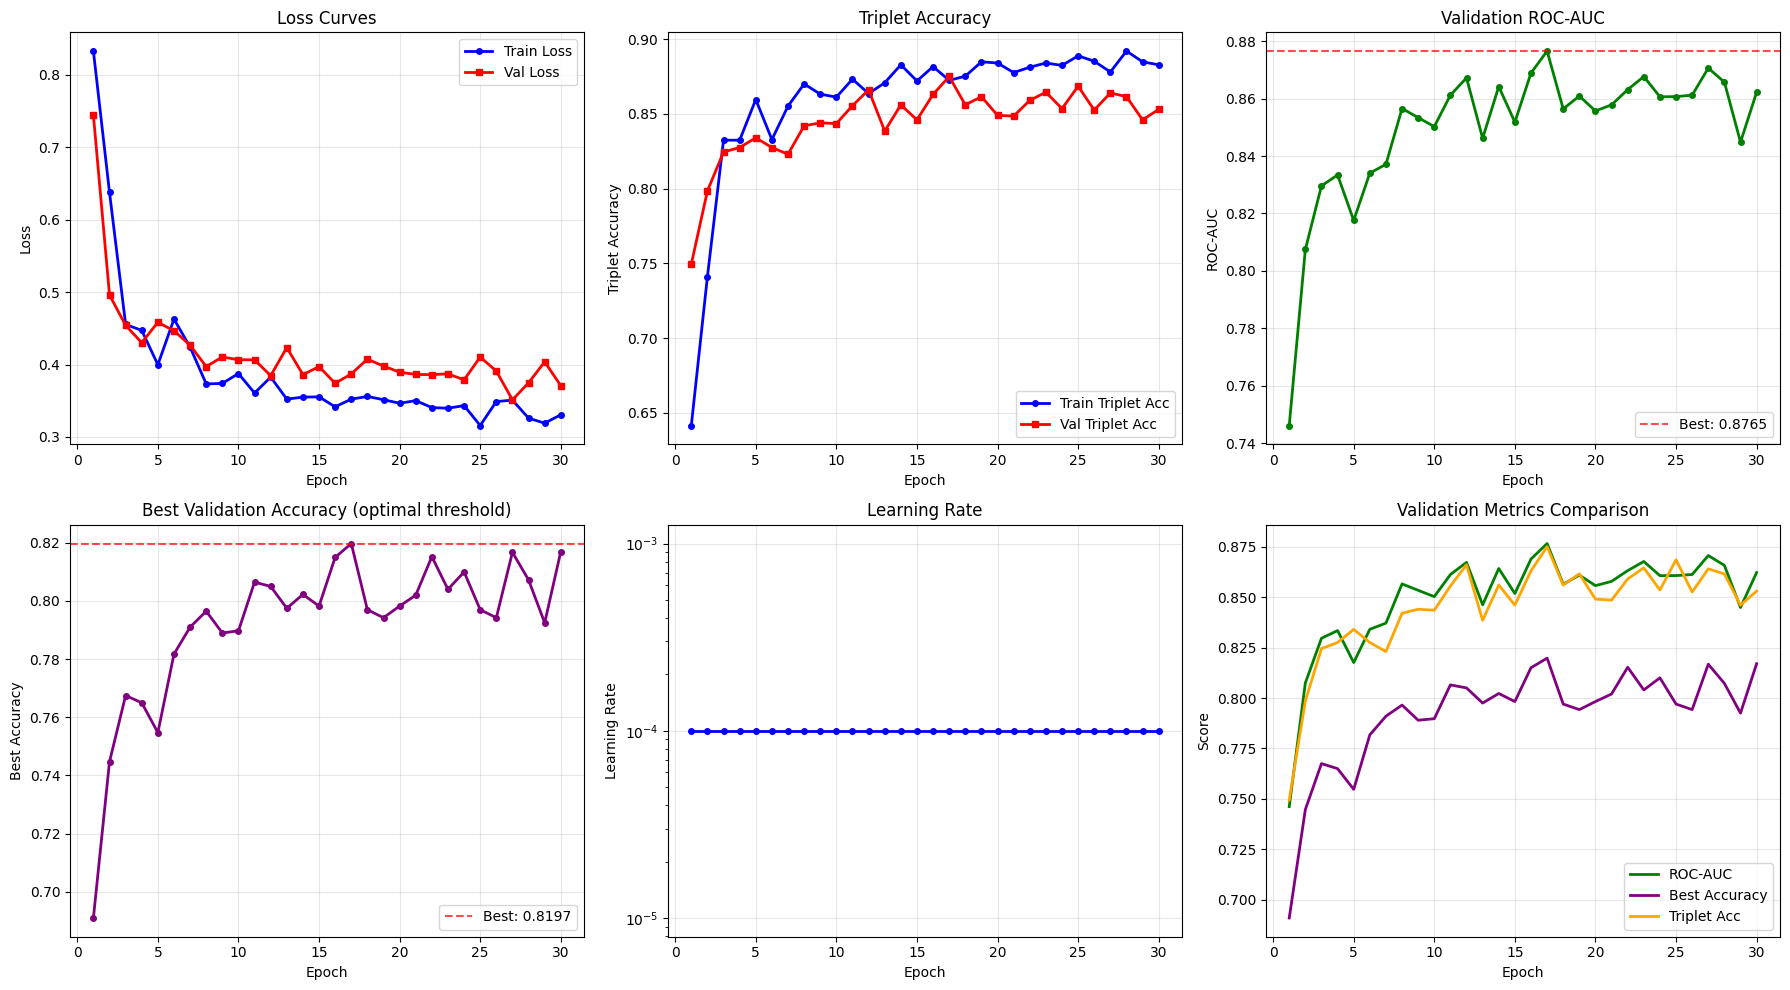


Best Val ROC-AUC: 0.8765 (Epoch 17)
Best Val Accuracy: 0.8197 (Epoch 17)
Best Val Triplet Acc: 0.8750 (Epoch 17)

Final Epoch (30):
  Val ROC-AUC: 0.8622
  Val Accuracy: 0.8170
  Val Triplet Acc: 0.8530
  Train Loss: 0.3306
  Val Loss: 0.3708


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss curves
axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Triplet Accuracy
axes[0, 1].plot(epochs, history['train_triplet_accuracy'], 'b-o', label='Train Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_triplet_accuracy'], 'r-s', label='Val Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Triplet Accuracy')
axes[0, 1].set_title('Triplet Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC
axes[0, 2].plot(epochs, history['val_roc_auc'], 'g-o', linewidth=2, markersize=4)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('Validation ROC-AUC')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=max(history['val_roc_auc']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history['val_roc_auc']):.4f}")
axes[0, 2].legend()

# 4. Best Validation Accuracy
axes[1, 0].plot(epochs, history['val_best_accuracy'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Best Accuracy')
axes[1, 0].set_title('Best Validation Accuracy (optimal threshold)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=max(history['val_best_accuracy']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history['val_best_accuracy']):.4f}")
axes[1, 0].legend()

# 5. Learning Rate
axes[1, 1].plot(epochs, history['lr'], 'b-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 6. Combined metrics on one plot (optional)
axes[1, 2].plot(epochs, history['val_roc_auc'], 'g-', label='ROC-AUC', linewidth=2)
axes[1, 2].plot(epochs, history['val_best_accuracy'], 'purple', label='Best Accuracy', linewidth=2)
axes[1, 2].plot(epochs, history['val_triplet_accuracy'], 'orange', label='Triplet Acc', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Validation Metrics Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


best_roc_auc_idx = np.argmax(history['val_roc_auc'])
best_acc_idx = np.argmax(history['val_best_accuracy'])
best_triplet_idx = np.argmax(history['val_triplet_accuracy'])

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc']):.4f} (Epoch {best_roc_auc_idx + 1})")
print(f"Best Val Accuracy: {max(history['val_best_accuracy']):.4f} (Epoch {best_acc_idx + 1})")
print(f"Best Val Triplet Acc: {max(history['val_triplet_accuracy']):.4f} (Epoch {best_triplet_idx + 1})")

print(f"\nFinal Epoch (30):")
print(f"  Val ROC-AUC: {history['val_roc_auc'][-1]:.4f}")
print(f"  Val Accuracy: {history['val_best_accuracy'][-1]:.4f}")
print(f"  Val Triplet Acc: {history['val_triplet_accuracy'][-1]:.4f}")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")


In [39]:
checkpoint = torch.load('best_triplet_model.pth', weights_only=False)
torch.save(checkpoint, 'best_triplet_vit_model_final.pth')
print("Best checkpoint saved")

Best checkpoint saved
